# Notebook Visual Analysis

In [ ]:
import xarray as xr 
import numpy as np 
import proplot 
import matplotlib.pyplot as plt
import cmocean
from pyinterp import fill, Axis, TemporalAxis, Grid3D, Grid2D
n_workers = 10
plt.rcdefaults()
import matplotlib.ticker as mticker 

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

import colorcet as cc
import proplot

from scipy.ndimage import gaussian_filter

In [ ]:
path_data = "../.." # Change path according to where data are saved

In [44]:
lon_min = 190; lon_max = 200
lat_min = 20; lat_max = 30

In [ ]:
%run ./functions_interp.ipynb

## 1) Loading 

### a) Reference field 

In [ ]:
ds_truth = xr.open_dataset(f"{path_data}/data/OSSE/ref/2023e_SSHmapping_HF_Hawaii_eval_2012-06-15.nc")
ds_truth = ds_truth.sel(longitude=slice(lon_min,lon_max),
                        latitude=slice(lat_min,lat_max),drop=True)
ssh_bm_truth = ds_truth.ssh_bm.load()
ssh_it_truth = ds_truth.ssh_it.load()
ssh_tot_truth = ds_truth.ssh.load()

In [ ]:
ssh_bm_truth = fill_nan(ssh_bm_truth)
ssh_it_truth = fill_nan(ssh_it_truth)
ssh_tot_truth = fill_nan(ssh_tot_truth)

In [ ]:
ssh_bm_truth_filtered = gaussian_filter(ssh_bm_truth.values, sigma=(1.2, 1.2),axes=(1,2))
ssh_bm_truth = gaussian_filter(ssh_bm_truth.values, sigma=(0, 0),axes=(1,2))

### b) Reconstructed field 

In [ ]:
ds_QGSW = xr.open_dataset(f"{path_data}/data/mapping_outputs/config_QGSW/config_QGSW_y2012m06d15h00m00.nc")
# - BALANCED MOTIONS BM - #
ssh_bm_QGSW = ds_QGSW.ssh_bm.load()
ssh_bm_QGSW = ssh_bm_QGSW.rename({"lon":"longitude","lat":"latitude"})
# - INTERNAL TIDE IT - #
ssh_it_QGSW = ds_QGSW.ssh_it.load()
ssh_it_QGSW = ssh_it_QGSW.rename({"lon":"longitude","lat":"latitude"})

In [ ]:
ds_QG = xr.open_dataset(f"{path_data}/data/mapping_outputs/config_QG/config_QG_y2012m06d15h00m00.nc")
# - BALANCED MOTIONS BM - #
ssh_bm_QG = ds_QG.ssh_bm.load()
ssh_bm_QG = ssh_bm_QG.rename({"lon":"longitude","lat":"latitude"})

## 2) Functions 

### a) Common parameters 

In [ ]:
dx_16 = 6279.4406571041745 # Zonal size in km of grid step 
dy_16 = 6937.5 # Meridional size in km of grid step 

In [ ]:
f = np.ones_like(ssh_bm_QGSW[0,:,:])*4*np.pi/86164*np.sin((0.5*lat_min+0.5*lat_max)*np.pi/180)

### a) Geostrophic velocities 

In [ ]:
g=9.81
def h2uv(h,dx,dy):
    f = np.ones_like(h)*4*np.pi/86164*np.sin((0.5*lat_min+0.5*lat_max)*np.pi/180)

    u = np.zeros_like(h)
    v = np.zeros_like(h)

    u[1:-1,:] = (- g/f[1:-1,:]*\
        (h[2:,:]-h[:-2,:])/(2*dy))
            
    v[:,1:-1] = (g/f[:,1:-1]*\
        (h[:,2:]-h[:,:-2])/(2*dx))

    u = np.where(np.isnan(u),0,u)
    v = np.where(np.isnan(v),0,v)
    
    return u,v

### b) Vorticity

In [ ]:
g=9.81
def h2pv(h,dx,dy):
        f = np.ones_like(h)*4*np.pi/86164*np.sin((0.5*lat_min+0.5*lat_max)*np.pi/180)

        q = np.zeros_like(h)

        q[1:-1, 1:-1] =g / f[1:-1, 1:-1] * \
            ((h[2:, 1:-1] + h[:-2, 1:-1] - 2 * h[1:-1, 1:-1]) / dy ** 2 + \
             (h[1:-1, 2:] + h[1:-1, :-2] - 2 * h[1:-1, 1:-1]) / dx ** 2) 
        
        return q

## 3) Calculation 

In [ ]:
u_bm_QGSW, v_bm_QGSW = h2uv(ssh_bm_QGSW[0,:,:].values,dx_16,dy_16)
u_bm_QG, v_bm_QG = h2uv(ssh_bm_QG[0,:,:].values,dx_16,dy_16)
u_bm_truth, v_bm_truth = h2uv(ssh_bm_truth[0,:,:],dx_16,dy_16)

In [ ]:
vort_QGSW = h2pv(ssh_bm_QGSW[0,:,:].values,dx_16,dy_16)
vort_QG = h2pv(ssh_bm_QG[0,:,:].values,dx_16,dy_16)
vort_truth = h2pv(ssh_bm_truth[0,:,:],dx_16,dy_16)

In [ ]:
sigma_uv = 1.35

u_bm_truth_filtered = gaussian_filter(u_bm_truth, sigma=(sigma_uv, sigma_uv),axes=(0,1))
v_bm_truth_filtered = gaussian_filter(v_bm_truth, sigma=(sigma_uv, sigma_uv),axes=(0,1))

u_bm_QGSW_filtered = gaussian_filter(u_bm_QGSW, sigma=(sigma_uv, sigma_uv),axes=(0,1))
v_bm_QGSW_filtered = gaussian_filter(v_bm_QGSW, sigma=(sigma_uv, sigma_uv),axes=(0,1))

u_bm_QG_filtered = gaussian_filter(u_bm_QG, sigma=(sigma_uv, sigma_uv),axes=(0,1))
v_bm_QG_filtered = gaussian_filter(v_bm_QG, sigma=(sigma_uv, sigma_uv),axes=(0,1))

In [ ]:
sigma_vort = 1.35

vort_truth_filtered = gaussian_filter(vort_truth, sigma=(sigma_vort, sigma_vort),axes=(0,1))
vort_QGSW_filtered = gaussian_filter(vort_QGSW, sigma=(sigma_vort, sigma_vort),axes=(0,1))
vort_QG_filtered = gaussian_filter(vort_QG, sigma=(sigma_vort, sigma_vort),axes=(0,1))

## 4) Figure **02**

In [24]:
v_min_bm = 100*0.7
v_max_bm = 100*1.05
v_min_it = 100*-0.06
v_max_it = 100*0.06
v_min_curr = 0
v_max_curr = 0.5
vmin_bathy = -7000
vmax_bathy = 0

In [45]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(12, 16), dpi=300)

outer_gs = fig.add_gridspec(4, 1, hspace=0.1)

ax = np.empty((4, 3), dtype=object)

for i in range(4):

    # One row
    row_gs = outer_gs[i]

    # Split into left (2 plots) + right (1 plot)
    sub_gs = row_gs.subgridspec(1, 2, width_ratios=[2, 0.93], wspace=0.3)

    # Left part → 2 columns
    left_gs = sub_gs[0].subgridspec(1, 2, wspace=0.2)

    ax[i, 0] = fig.add_subplot(left_gs[0, 0], projection=proj)
    ax[i, 1] = fig.add_subplot(left_gs[0, 1], projection=proj)

    # Right part → single plot
    ax[i, 2] = fig.add_subplot(sub_gs[1], projection=proj)

# BM SSH FIELD # 

_plt_bm_ref = ax[0,0].pcolormesh(ds_truth.longitude,ds_truth.latitude,100*ssh_bm_truth[0,:,:],cmap=cmocean.cm.haline,
                             vmin=v_min_bm,vmax=v_max_bm,transform=proj)
_plt_bm_rec = ax[0,1].pcolormesh(ssh_bm_QGSW.longitude,ssh_bm_QGSW.latitude,100*ssh_bm_QGSW[0,:,:],cmap=cmocean.cm.haline,
                             vmin=v_min_bm,vmax=v_max_bm,transform=proj)
_plt_bm_err = ax[0,2].pcolormesh(ssh_bm_QGSW.longitude,ssh_bm_QGSW.latitude,100*np.abs(ssh_bm_QGSW[0,:,:]-ssh_bm_truth[0,:,:]),cmap="Reds",
                             vmin=0,vmax=6,transform=proj)

# GEOST CURRENT #

_plt_curr_ref = ax[1,0].pcolormesh(ds_truth.longitude,ds_truth.latitude,np.sqrt(u_bm_truth_filtered**2+v_bm_truth_filtered**2),cmap=cmocean.cm.ice,
                             vmin=v_min_curr,vmax=v_max_curr,transform=proj)
_plt_curr_rec = ax[1,1].pcolormesh(ssh_bm_QGSW.longitude,ssh_bm_QGSW.latitude,np.sqrt(u_bm_QGSW_filtered**2+v_bm_QGSW_filtered**2),cmap=cmocean.cm.ice,
                             vmin=v_min_curr,vmax=v_max_curr,transform=proj)
_plt_curr_err = ax[1,2].pcolormesh(ssh_bm_QGSW.longitude,ssh_bm_QGSW.latitude,np.abs(np.sqrt(u_bm_QGSW**2+v_bm_QGSW**2)-np.sqrt(u_bm_truth**2+v_bm_truth**2)),
                                   cmap='Reds',vmin=0,vmax=0.3,transform=proj)

# REL VORT #
cmap_vort=cmocean.cm.balance

_plt_vort_ref = ax[2,0].pcolormesh(ds_truth.longitude,ds_truth.latitude,vort_truth_filtered/f,cmap=cmap_vort,
                             vmin=-0.5,vmax=0.5,transform=proj)
_plt_vort_rec = ax[2,1].pcolormesh(ssh_bm_QGSW.longitude,ssh_bm_QGSW.latitude,vort_QGSW_filtered/f,cmap=cmap_vort,
                             vmin=-0.5,vmax=0.5,transform=proj)
_plt_vort_err = ax[2,2].pcolormesh(ssh_bm_QGSW.longitude,ssh_bm_QGSW.latitude,np.abs(vort_QGSW_filtered-vort_truth_filtered)/f,cmap='Reds',
                             vmin=0,vmax=0.3,transform=proj)


# IT SSH FIELD # 

_plt_it_ref = ax[-1,0].pcolormesh(ds_truth.longitude,ds_truth.latitude,100*ssh_it_truth[0,:,:],cmap="bwr",
                             vmin=v_min_it,vmax=v_max_it,transform=proj)
_plt_it_rec = ax[-1,1].pcolormesh(ssh_it_QGSW.longitude,ssh_it_QGSW.latitude,100*ssh_it_QGSW[0,:,:],cmap="bwr",
                             vmin=v_min_it,vmax=v_max_it,transform=proj)
_plt_it_err = ax[-1,2].pcolormesh(ssh_it_QGSW.longitude,ssh_it_QGSW.latitude,100*np.abs(ssh_it_truth[0,:,:]-ssh_it_QGSW[0,:,:]),cmap="Reds",
                             vmin=0,vmax=6,transform=proj)

### MAP FEATURES ###

lon_ticks = np.arange(-168, -160, 2)
lat_ticks = np.arange(lat_min, lat_max+1, 2)

for i in range(4):
    ax[i,0].set_title(f"reference",fontsize=14)
    ax[i,1].set_title(f"reconstruction",fontsize=14)
    ax[i,2].set_title(f"error",fontsize=14)

cbar_ax_bm = fig.add_axes([0.605, 0.715, 0.008, 0.14])  # between left and right sections
cbar_bm = fig.colorbar(_plt_bm_ref, cax=cbar_ax_bm, extend='both', shrink=0.9, aspect=30)
cbar_bm.ax.tick_params(labelsize=9)
cbar_bm.ax.set_title("[cm]", fontsize=10)

cbar_ax_bm_err = fig.add_axes([0.92, 0.715, 0.008, 0.14])  # between left and right sections
cbar_bm_err = fig.colorbar(_plt_bm_err, cax=cbar_ax_bm_err, extend='max', shrink=0.9, aspect=30)
cbar_bm_err.ax.tick_params(labelsize=9)
cbar_bm_err.ax.set_title("[cm]", fontsize=10)

cbar_ax_curr = fig.add_axes([0.605, 0.517, 0.008, 0.14])  # between left and right sections
cbar_curr = fig.colorbar(_plt_curr_ref, cax=cbar_ax_curr, extend='both', shrink=0.9, aspect=30)
cbar_curr.ax.tick_params(labelsize=9)
cbar_curr.ax.set_title("[m/s]", fontsize=10)

cbar_ax_curr_err = fig.add_axes([0.92, 0.517, 0.008, 0.14])  # between left and right sections
cbar_curr_err = fig.colorbar(_plt_curr_err, cax=cbar_ax_curr_err, extend='max', shrink=0.9, aspect=30)
cbar_curr_err.ax.tick_params(labelsize=9)
cbar_curr_err.ax.set_title("[m/s]", fontsize=10)

cbar_ax_vort = fig.add_axes([0.605, 0.321, 0.008, 0.14])  # between left and right sections
cbar_vort = fig.colorbar(_plt_vort_ref, cax=cbar_ax_vort, extend='both', shrink=0.9, aspect=30)
cbar_vort.ax.tick_params(labelsize=9)
cbar_vort.ax.set_title("", fontsize=10)

cbar_ax_vort_err = fig.add_axes([0.92, 0.321, 0.008, 0.14])  # between left and right sections
cbar_vort_err = fig.colorbar(_plt_vort_err, cax=cbar_ax_vort_err, extend='max', shrink=0.9, aspect=30)
cbar_vort_err.ax.tick_params(labelsize=9)
cbar_vort_err.ax.set_title("", fontsize=10)

cbar_ax_it = fig.add_axes([0.605, 0.124, 0.008, 0.14])  # between left and right sections
cbar_it = fig.colorbar(_plt_it_ref, cax=cbar_ax_it, extend='both', shrink=0.9, aspect=30)
cbar_it.ax.tick_params(labelsize=9)
cbar_it.ax.set_title("[cm]", fontsize=10)

cbar_ax_it_err = fig.add_axes([0.92, 0.124, 0.008, 0.14])  # between left and right sections
cbar_it_err = fig.colorbar(_plt_it_err, cax=cbar_ax_it_err, extend='max', shrink=0.9, aspect=30)
cbar_it_err.ax.tick_params(labelsize=9)
cbar_it_err.ax.set_title("[cm]", fontsize=10)


for i,_ax in enumerate(ax.flatten()):

    _ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    _ax.coastlines(resolution='50m', color='black', linewidth=1)

    _ax.add_feature(cfeature.LAND.with_scale('50m'),facecolor='darkgray',zorder=3)

    # ticks
    _ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    _ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())

    _ax.xaxis.set_major_formatter(LongitudeFormatter())
    _ax.yaxis.set_major_formatter(LatitudeFormatter())

    _ax.tick_params(labelsize=11)

    _ax.tick_params(axis='both',which='major',direction='in',length=3,width=1.,labelsize=8)

    if i in [0,1,3,4]:
        alpha=0.6
        color="white"
    else:
        alpha=0.4
        color="black"
    
    gl = _ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=False,linewidth=0.2,color=color,alpha=alpha,linestyle='-')

    gl.xlocator = mticker.FixedLocator(lon_ticks)
    gl.ylocator = mticker.FixedLocator(lat_ticks)


text_array = [r"$\eta^{BM}$",r"$||\mathbf{u^{BM}}||$",r"$\frac{\zeta^{BM}}{f}$",r"$\eta^{IT}$"]
fontsize_array = [24,18,28,24]
offset_array = [0,0.08,0,0]
for i in range(4):
    ax[i,0].text(
        -0.5-offset_array[i], 0.5,
        text_array[i],
        transform=ax[i,0].transAxes,
        # rotation=90,
        va='center',
        fontsize=fontsize_array[i],
        fontweight='bold'
    )

/home/bellemva/miniconda3/envs/plot_env/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1781: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  result = super().pcolormesh(*args, **kwargs)
/home/bellemva/miniconda3/envs/plot_env/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1781: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  result = super().pcolormesh(*args, **kwargs)
/home/bellemva/miniconda3/envs/plot_env/lib/python3.10/site-packages/cartopy/mpl/geo

## 4) Figure **06**

In [47]:
lat_min = ds_QG.lat[75]; lat_max = ds_QG.lat[100]
lon_min = ds_QG.lon[40]; lon_max = ds_QG.lon[90]

In [84]:
v_min_bm = 100*0.8
v_max_bm = 100*1.02
v_min_curr = 0
v_max_curr = 0.4
v_min_vort = -0.45
v_max_vort = 0.45

/home/bellemva/miniconda3/envs/plot_env/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1781: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  result = super().pcolormesh(*args, **kwargs)
/home/bellemva/miniconda3/envs/plot_env/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1781: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  result = super().pcolormesh(*args, **kwargs)
/home/bellemva/miniconda3/envs/plot_env/lib/python3.10/site-packages/cartopy/mpl/geo

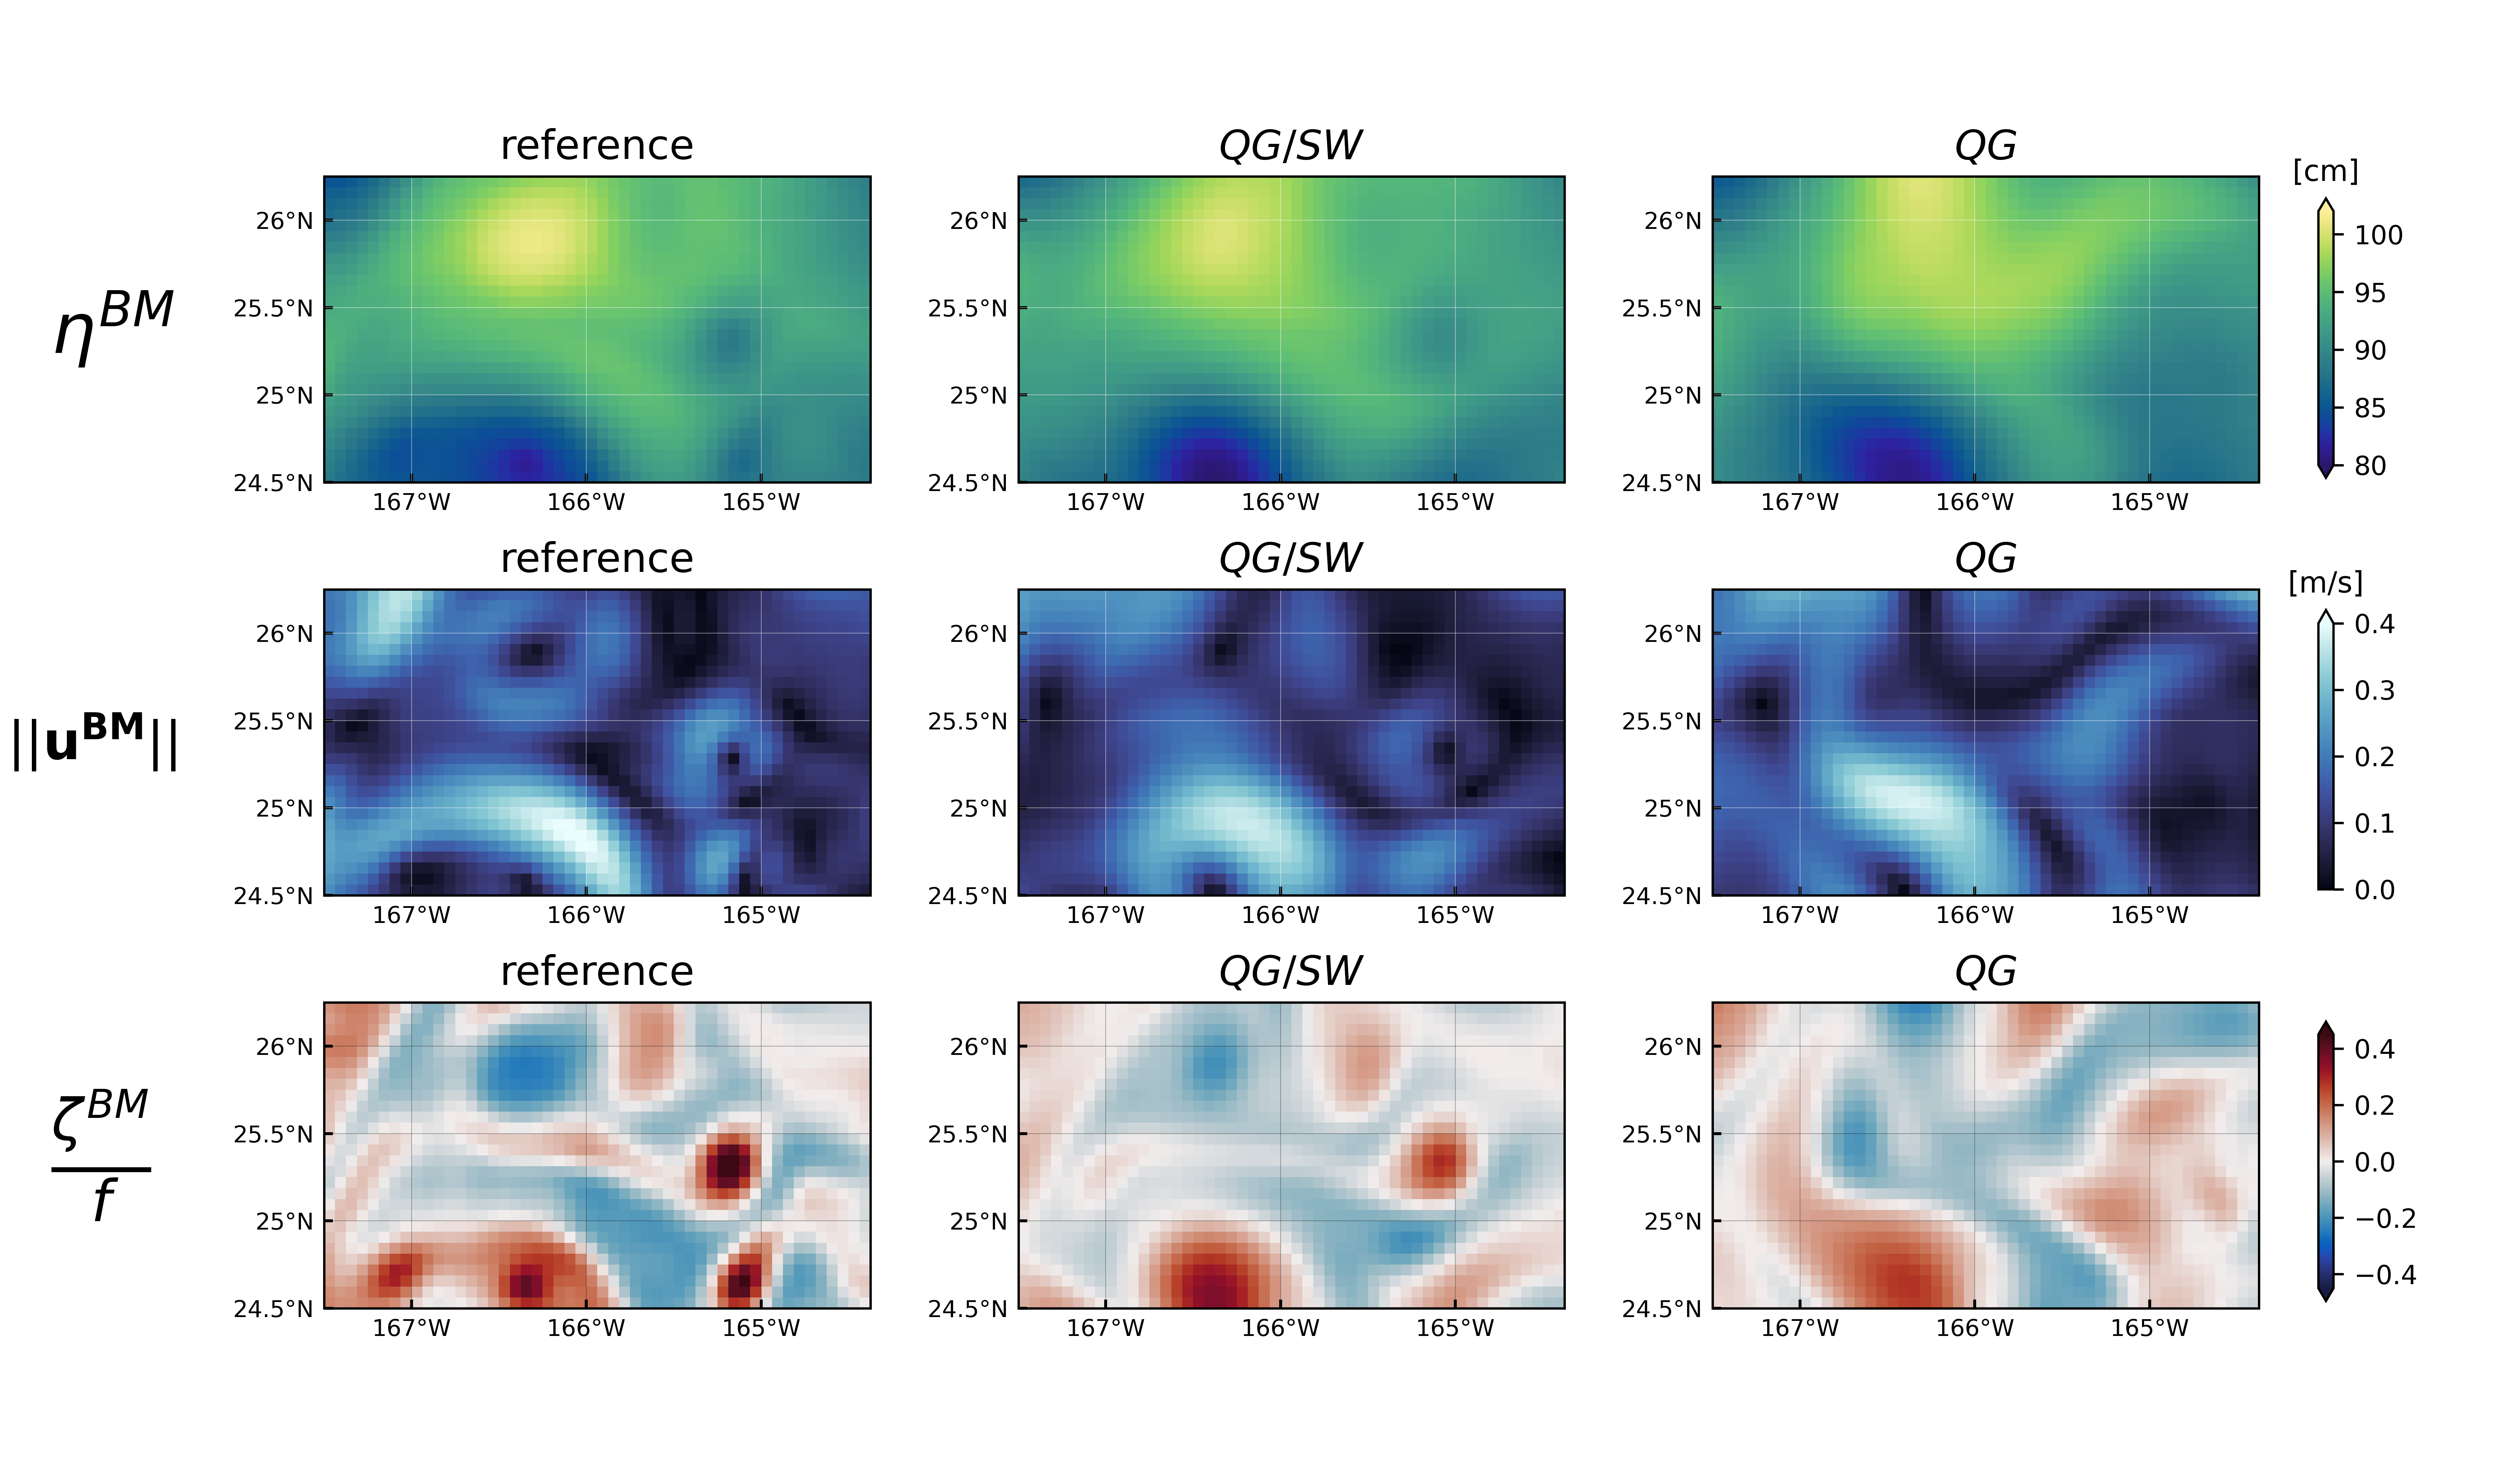

In [104]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(12, 7), dpi=300)

outer_gs = fig.add_gridspec(3, 1, hspace=0.35)

ax = np.empty((3, 3), dtype=object)

for i in range(3):

    # One row
    row_gs = outer_gs[i]

    # Split into left (2 plots) + right (1 plot)
    sub_gs = row_gs.subgridspec(1, 3, wspace=0.23)

    ax[i, 0] = fig.add_subplot(sub_gs[0], projection=proj)
    ax[i, 1] = fig.add_subplot(sub_gs[1], projection=proj)
    ax[i, 2] = fig.add_subplot(sub_gs[2], projection=proj)


# BM SSH FIELD # 
_plt_bm_ref = ax[0,0].pcolormesh(ds_truth.longitude,ds_truth.latitude,100*ssh_bm_truth[0,:,:],cmap=cmocean.cm.haline,
                             vmin=v_min_bm,vmax=v_max_bm,transform=proj)
_plt_bm_QGSW = ax[0,1].pcolormesh(ssh_bm_QGSW.longitude,ssh_bm_QGSW.latitude,100*ssh_bm_QGSW[0,:,:],cmap=cmocean.cm.haline,
                             vmin=v_min_bm,vmax=v_max_bm,transform=proj)
_plt_bm_QG = ax[0,2].pcolormesh(ssh_bm_QG.longitude,ssh_bm_QG.latitude,100*ssh_bm_QG[0,:,:],cmap=cmocean.cm.haline,
                             vmin=v_min_bm,vmax=v_max_bm,transform=proj)

# GEOST CURRENT #
_plt_curr_ref = ax[1,0].pcolormesh(ds_truth.longitude,ds_truth.latitude,np.sqrt(u_bm_truth_filtered**2+v_bm_truth_filtered**2),cmap=cmocean.cm.ice,
                             vmin=v_min_curr,vmax=v_max_curr,transform=proj)
_plt_curr_QGSW = ax[1,1].pcolormesh(ssh_bm_QGSW.longitude,ssh_bm_QGSW.latitude,np.sqrt(u_bm_QGSW_filtered**2+v_bm_QGSW_filtered**2),cmap=cmocean.cm.ice,
                             vmin=v_min_curr,vmax=v_max_curr,transform=proj)
_plt_curr_QG = ax[1,2].pcolormesh(ssh_bm_QG.longitude,ssh_bm_QG.latitude,np.sqrt(u_bm_QG_filtered**2+v_bm_QG_filtered**2),cmap=cmocean.cm.ice,
                             vmin=v_min_curr,vmax=v_max_curr,transform=proj)

# REL VORT #
cmap_vort=cmocean.cm.balance
_plt_vort_ref = ax[2,0].pcolormesh(ds_truth.longitude,ds_truth.latitude,vort_truth_filtered/f,cmap=cmap_vort,
                             vmin=v_min_vort,vmax=v_max_vort,transform=proj)
_plt_vort_rec = ax[2,1].pcolormesh(ssh_bm_QGSW.longitude,ssh_bm_QGSW.latitude,vort_QGSW_filtered/f,cmap=cmap_vort,
                             vmin=v_min_vort,vmax=v_max_vort,transform=proj)
_plt_vort_err = ax[2,2].pcolormesh(ssh_bm_QG.longitude,ssh_bm_QG.latitude,vort_QG_filtered/f,cmap=cmap_vort,
                             vmin=v_min_vort,vmax=v_max_vort,transform=proj)

### MAP FEATURES ###
lon_ticks = np.arange(-168, -160, 2)
lat_ticks = np.arange(lat_min, lat_max+1, 2)

for i in range(3):
    ax[i,0].set_title(f"reference",fontsize=14)
    ax[i,1].set_title(r"$QG/SW$",fontsize=14)
    ax[i,2].set_title(r"$QG$",fontsize=14)

lon_ticks = np.arange(-167, -164.5, 1)
lat_ticks = np.arange(24.5,26.25, 0.5)

for i,_ax in enumerate(ax.flatten()):

    _ax.set_extent([float(ssh_bm_QG.longitude[40]),float(ssh_bm_QG.longitude[90]),float(ssh_bm_QG.latitude[75]),float(ssh_bm_QG.latitude[100]),],crs=proj)

    # ticks
    _ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    _ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())

    _ax.xaxis.set_major_formatter(LongitudeFormatter())
    _ax.yaxis.set_major_formatter(LatitudeFormatter())

    _ax.tick_params(labelsize=11)

    _ax.tick_params(axis='both',which='major',direction='in',length=3,width=1.,labelsize=8)

    if i in [0,1,2,3,4,5]:
        alpha=0.6
        color="white"
    else:
        alpha=0.4
        color="black"

    gl = _ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=False,linewidth=0.2,color=color,alpha=alpha,linestyle='-')
    gl.xlocator = mticker.FixedLocator(lon_ticks)
    gl.ylocator = mticker.FixedLocator(lat_ticks)

cbar_ax_bm = fig.add_axes([0.92, 0.675, 0.006, 0.19])  # between left and right sections
cbar_bm = fig.colorbar(_plt_bm_ref, cax=cbar_ax_bm, extend='both', shrink=0.9, aspect=30)
cbar_bm.ax.tick_params(labelsize=9)
cbar_bm.ax.set_title("[cm]", fontsize=10)

cbar_ax_curr = fig.add_axes([0.92, 0.395, 0.006, 0.19])  # between left and right sections
cbar_curr = fig.colorbar(_plt_curr_ref, cax=cbar_ax_curr, extend='max', shrink=0.9, aspect=30)
cbar_curr.ax.tick_params(labelsize=9)
cbar_curr.ax.set_title("[m/s]", fontsize=10)

cbar_ax_vort = fig.add_axes([0.92, 0.115, 0.006, 0.19])  # between left and right sections
cbar_vort = fig.colorbar(_plt_vort_ref, cax=cbar_ax_vort, extend='both', shrink=0.9, aspect=30)
cbar_vort.ax.tick_params(labelsize=9)
cbar_vort.ax.set_title("", fontsize=10)

text_array = [r"$\eta^{BM}$",r"$||\mathbf{u^{BM}}||$",r"$\frac{\zeta^{BM}}{f}$"]
fontsize_array = [24,18,28]
offset_array = [0,0.08,0]
for i in range(3):
    ax[i,0].text(
        -0.5-offset_array[i], 0.5,
        text_array[i],
        transform=ax[i,0].transAxes,
        # rotation=90,
        va='center',
        fontsize=fontsize_array[i],
        fontweight='bold'
    )